In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# Graph style (for better output)
plt.style.use('ggplot')

In [2]:
from google.colab import files
files.upload()

Saving clean_sales_data.csv to clean_sales_data.csv


{'clean_sales_data.csv': b'Date,Sales\n2023-01-01,214\n2023-01-02,435\n2023-01-03,456\n2023-01-04,227\n2023-01-05,381\n2023-01-06,369\n2023-01-07,405\n2023-01-08,431\n2023-01-09,431\n2023-01-10,433\n2023-01-11,364\n2023-01-12,498\n2023-01-13,470\n2023-01-14,229\n2023-01-15,279\n2023-01-16,317\n2023-01-17,363\n2023-01-18,455\n2023-01-19,364\n2023-01-20,409\n2023-01-21,314\n2023-01-22,395\n2023-01-23,284\n2023-01-24,224\n2023-01-25,308\n2023-01-26,480\n2023-01-27,409\n2023-01-28,320\n2023-01-29,404\n2023-01-30,440\n2023-01-31,319\n2023-02-01,465\n2023-02-02,377\n2023-02-03,401\n2023-02-04,273\n2023-02-05,200\n2023-02-06,231\n2023-02-07,236\n2023-02-08,419\n2023-02-09,237\n2023-02-10,470\n2023-02-11,214\n2023-02-12,222\n2023-02-13,494\n2023-02-14,212\n2023-02-15,218\n2023-02-16,332\n2023-02-17,268\n2023-02-18,414\n2023-02-19,389\n2023-02-20,206\n2023-02-21,249\n2023-02-22,284\n2023-02-23,492\n2023-02-24,327\n2023-02-25,331\n2023-02-26,240\n2023-02-27,211\n2023-02-28,488\n2023-03-01,202\n2

In [3]:
data = pd.read_csv('clean_sales_data.csv')

# Convert date
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Ensure daily frequency
data = data.asfreq('D')

In [4]:
# Fill missing values
data['Sales'] = data['Sales'].fillna(method='ffill')

print(data.head())

            Sales
Date             
2023-01-01    214
2023-01-02    435
2023-01-03    456
2023-01-04    227
2023-01-05    381


/tmp/ipykernel_803/3939620559.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Sales'] = data['Sales'].fillna(method='ffill')


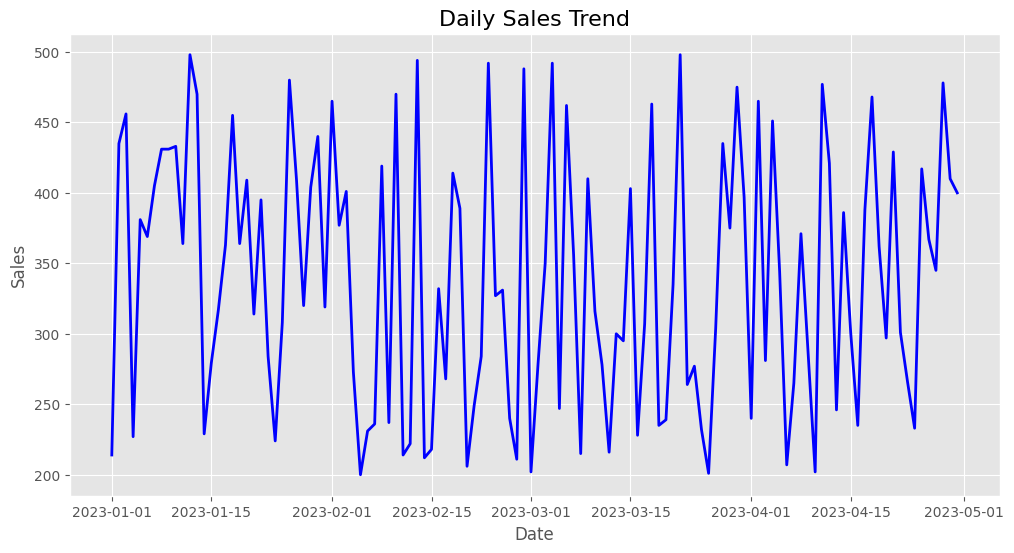

In [5]:
plt.figure(figsize=(12,6))

plt.plot(data['Sales'], color='blue', linewidth=2)
plt.title("Daily Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [6]:
train = data[:int(0.8*len(data))]
test = data[int(0.8*len(data)):]

In [7]:
model = SARIMAX(train['Sales'],
                order=(1,1,1),
                seasonal_order=(1,1,1,7))

model_fit = model.fit()
print(model_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -537.193
Date:                           Sun, 26 Apr 2026   AIC                           1084.387
Time:                                   05:29:10   BIC                           1096.773
Sample:                               01-01-2023   HQIC                          1089.377
                                    - 04-06-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0747      0.137     -0.547      0.584      -0.342       0.193
ma.L1         -0.9996      5.482     -0.182

In [8]:
forecast = model_fit.forecast(steps=len(test))

In [9]:
mae = mean_absolute_error(test['Sales'], forecast)
print("MAE:", mae)

MAE: 76.76552855191994


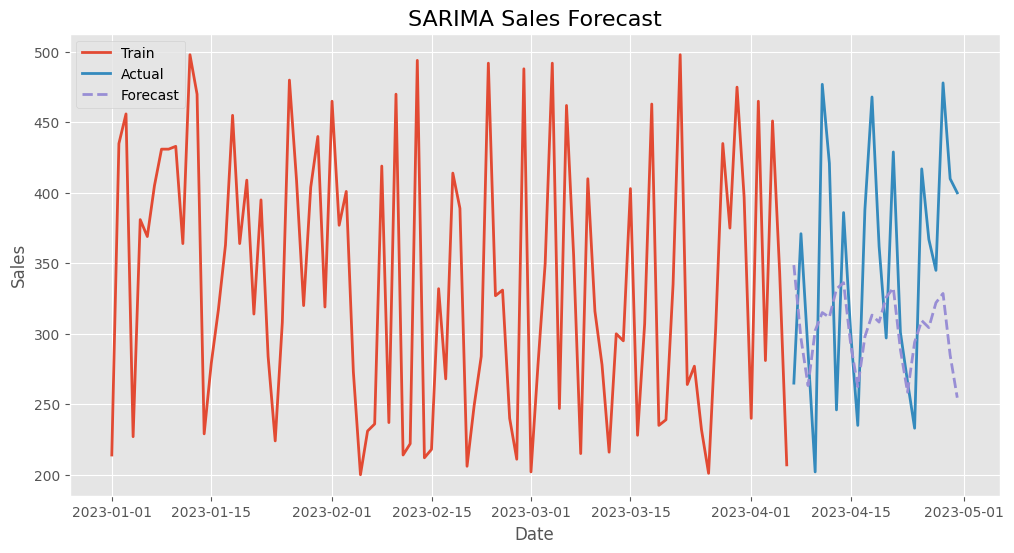

In [10]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Sales'], label='Train', linewidth=2)
plt.plot(test.index, test['Sales'], label='Actual', linewidth=2)
plt.plot(test.index, forecast, label='Forecast', linestyle='dashed', linewidth=2)

plt.title("SARIMA Sales Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

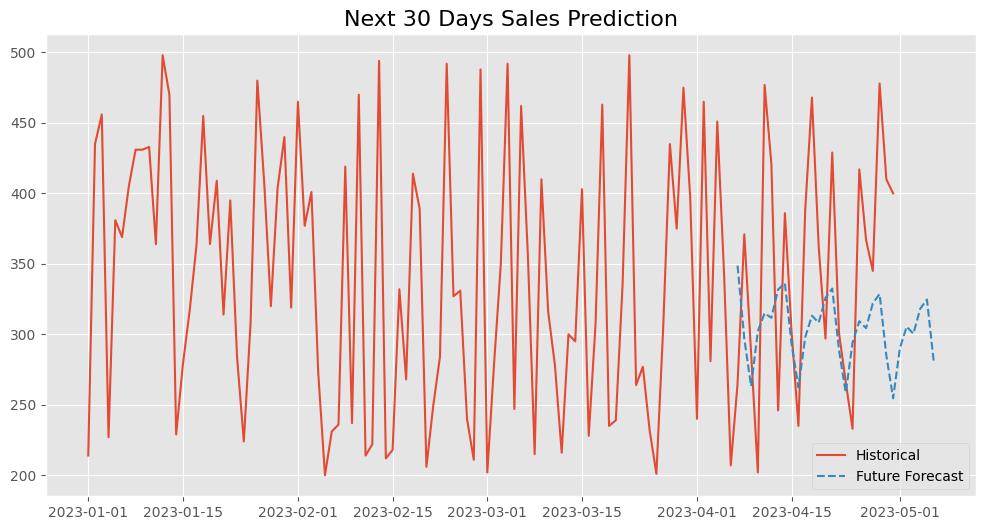

2023-04-07    348.732038
2023-04-08    296.811682
2023-04-09    263.238012
2023-04-10    302.200533
2023-04-11    315.035745
2023-04-12    311.711441
2023-04-13    331.851385
2023-04-14    336.259109
2023-04-15    292.635768
2023-04-16    262.481170
2023-04-17    297.908011
2023-04-18    313.270602
2023-04-19    308.276648
2023-04-20    325.885432
2023-04-21    332.505113
2023-04-22    288.748128
2023-04-23    258.538457
2023-04-24    294.022249
2023-04-25    309.344130
2023-04-26    304.377070
2023-04-27    322.026625
2023-04-28    328.610677
2023-04-29    284.855845
2023-04-30    254.647061
2023-05-01    290.129935
2023-05-02    305.452472
2023-05-03    300.484979
2023-05-04    318.133877
2023-05-05    324.718503
2023-05-06    280.963636
Freq: D, Name: predicted_mean, dtype: float64


In [11]:
future = model_fit.forecast(steps=30)

plt.figure(figsize=(12,6))

plt.plot(data.index, data['Sales'], label='Historical')
plt.plot(future.index, future, label='Future Forecast', linestyle='dashed')

plt.title("Next 30 Days Sales Prediction", fontsize=16)
plt.legend()
plt.grid(True)

plt.show()

print(future)

In [14]:
print(data.index)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-04-21', '2023-04-22', '2023-04-23', '2023-04-24',
               '2023-04-25', '2023-04-26', '2023-04-27', '2023-04-28',
               '2023-04-29', '2023-04-30'],
              dtype='datetime64[ns]', name='Date', length=120, freq='D')


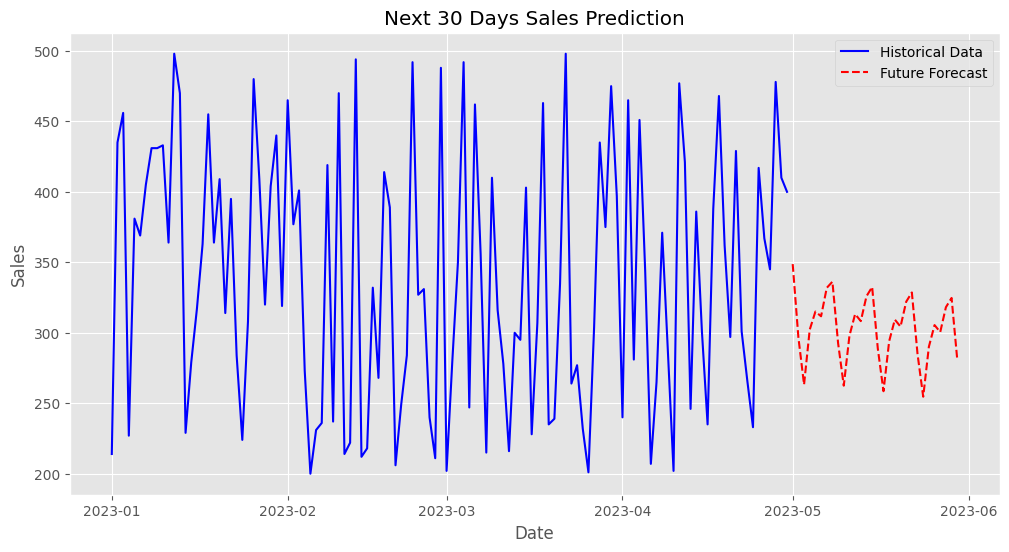

In [15]:
# Future Forecast (Next 30 Days) - Complete Code

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Get last date
last_date = data.index[-1]

# Step 2: Create future dates
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

# Step 3: Generate forecast
future_values = model_fit.forecast(steps=30)

# Step 4: Assign future dates to forecast
future = pd.Series(future_values.values, index=future_dates)

# Step 5: Plot
plt.figure(figsize=(12,6))

plt.plot(data.index, data['Sales'], label='Historical Data', color='blue')
plt.plot(future.index, future, label='Future Forecast', linestyle='dashed', color='red')

plt.title("Next 30 Days Sales Prediction")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

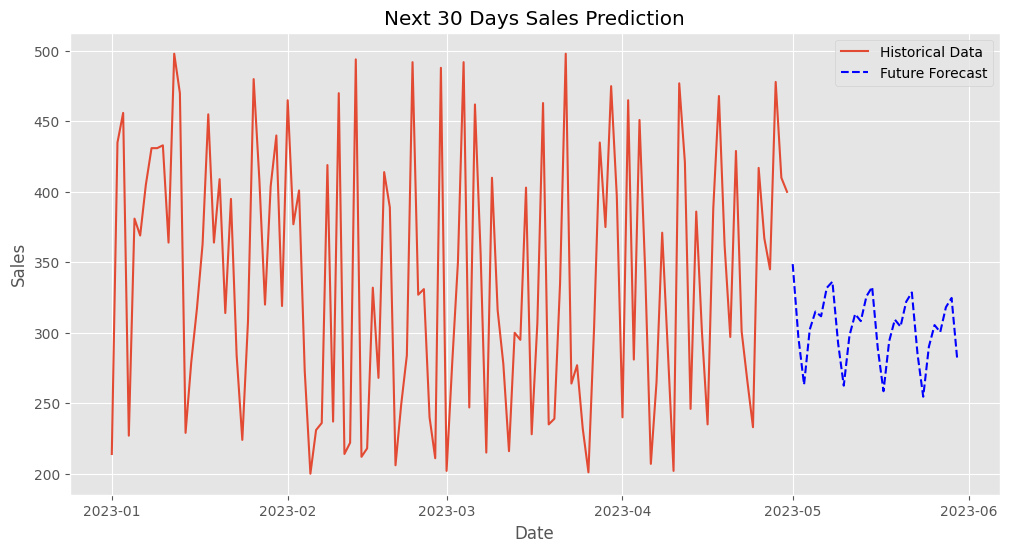

In [17]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data['Sales'], label='Historical Data')
plt.plot(future.index, future, label='Future Forecast', linestyle='dashed', color='blue')

plt.title("Next 30 Days Sales Prediction")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)
plt.show()

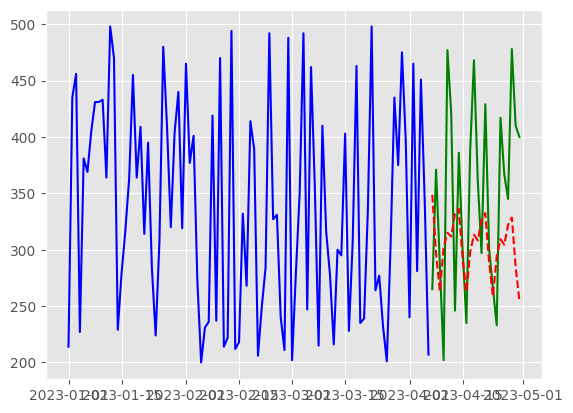

In [20]:
plt.plot(train.index, train['Sales'], color='blue', label='Train')
plt.plot(test.index, test['Sales'], color='green', label='Actual')
plt.plot(test.index, forecast, color='red', linestyle='dashed', label='Forecast')

In [21]:
import pickle

# Save model
with open('sarima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

In [22]:
from google.colab import files
files.download('sarima_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>